In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

df.describe()

Shape: (15509, 10)

Columns:
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dty

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [7]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [8]:
df.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [9]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [10]:
# Remove rows with missing values
df = df.dropna()

# Check remaining missing values
print(df.isnull().sum())

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert categorical columns to numbers
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,229,7.0,8,629,1352,2272,319
3,#Yaaram,(2019),110 min,184,4.4,35,1335,1198,719,2148
5,...Aur Pyaar Ho Gaya,(1997),147 min,157,4.7,827,1530,378,75,2045
6,...Yahaan,(2005),142 min,289,7.4,"1,086",2044,692,1112,2524
8,?: A Question Mark,(2012),82 min,320,5.6,326,135,1934,1175,1013


In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert categorical columns to numbers
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,229,7.0,8,629,1352,2272,319
3,#Yaaram,(2019),110 min,184,4.4,35,1335,1198,719,2148
5,...Aur Pyaar Ho Gaya,(1997),147 min,157,4.7,827,1530,378,75,2045
6,...Yahaan,(2005),142 min,289,7.4,"1,086",2044,692,1112,2524
8,?: A Question Mark,(2012),82 min,320,5.6,326,135,1934,1175,1013


In [13]:
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [14]:
X = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Duration', 'Votes']]

y = df['Rating']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4527, 7)
(1132, 7)


In [17]:
# Remove " min" from Duration and convert to numeric
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)

df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [18]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')

df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [19]:
df = df.dropna()

In [20]:
X = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Duration', 'Votes']]

y = df['Rating']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [24]:
print(df.dtypes)

Name         object
Year         object
Duration      int64
Genre         int64
Rating      float64
Votes         int64
Director      int64
Actor 1       int64
Actor 2       int64
Actor 3       int64
dtype: object


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [28]:
# Predict movie ratings
y_pred = model.predict(X_test)

print("First 10 Predicted Ratings:")
print(y_pred[:10])

First 10 Predicted Ratings:
[5.678 6.559 5.832 4.864 6.322 5.545 5.588 5.533 5.88  6.117]


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.976840106007067
Mean Squared Error (MSE): 1.5290172941696114
R2 Score: 0.17428241357049368


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

    Feature  Importance
6     Votes    0.199483
0     Genre    0.175861
2   Actor 1    0.133075
3   Actor 2    0.128029
5  Duration    0.122357
1  Director    0.121306
4   Actor 3    0.119889


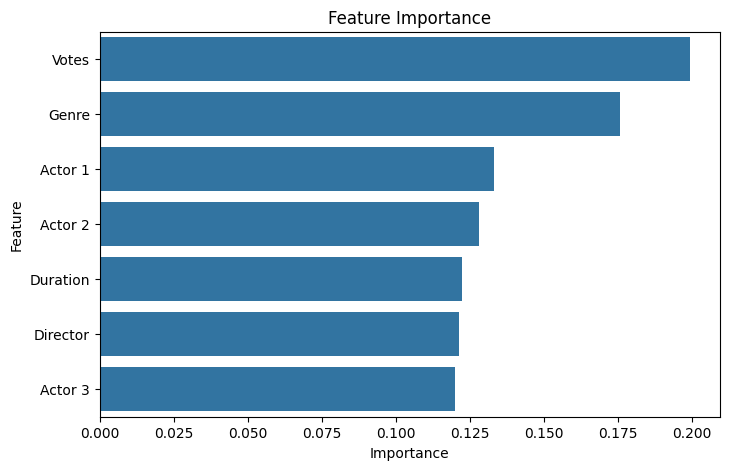

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(x='Importance', y='Feature', data=importance)

plt.title("Feature Importance")

plt.show()

## Conclusion

In this project, a Movie Rating Prediction model was built using the Random Forest Regressor. The dataset was cleaned, categorical features were encoded, and the model was evaluated using MAE, MSE, and R² Score. The feature importance graph helped identify the most influential factors affecting movie ratings.